In [ ]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['no', 'sphere', 'vort']
        self.file_paths = []
        self.labels = []
        
        for idx, cls_name in enumerate(self.classes):
            cls_path = os.path.join(root_dir, cls_name)
            for f in os.listdir(cls_path):
                if f.endswith('.npy'):
                    self.file_paths.append(os.path.join(cls_path, f))
                    self.labels.append(idx)

    def __len__(self): return len(self.file_paths)

    def __getitem__(self, idx):
        img = np.load(self.file_paths[idx])
        if len(img.shape) == 2: img = np.expand_dims(img, axis=0)
        img = torch.from_numpy(img).float()
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]


train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
])

base_path = '/kaggle/input/datasets/dundikuladeepeswar/dataset/dataset'
train_ds = LensingDataset(os.path.join(base_path, 'train'), transform=train_transforms)
val_ds = LensingDataset(os.path.join(base_path, 'val'))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
class LensingEnsemble(nn.Module):
    def __init__(self, num_classes=3):
        super(LensingEnsemble, self).__init__()
        # Backbone 1: ResNet18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.resnet.fc = nn.Identity() # Remove head
        
        # Backbone 2: DenseNet121 
        self.densenet = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        self.densenet.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.densenet.classifier = nn.Identity() # Remove head
        
        # Combined Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 + 1024, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat1 = self.resnet(x)
        feat2 = self.densenet(x)
        combined = torch.cat((feat1, feat2), dim=1)
        return self.classifier(combined)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LensingEnsemble().to(device)


criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 191MB/s]


Epoch 1/20 | Loss: 1.1041
Epoch 2/20 | Loss: 1.0327
Epoch 3/20 | Loss: 0.8392
Epoch 4/20 | Loss: 0.7069
Epoch 5/20 | Loss: 0.6451
Epoch 6/20 | Loss: 0.6100
Epoch 7/20 | Loss: 0.5844
Epoch 8/20 | Loss: 0.5631
Epoch 9/20 | Loss: 0.5476
Epoch 10/20 | Loss: 0.5313
Epoch 11/20 | Loss: 0.5212
Epoch 12/20 | Loss: 0.5075
Epoch 13/20 | Loss: 0.4997
Epoch 14/20 | Loss: 0.4913
Epoch 15/20 | Loss: 0.4825
Epoch 16/20 | Loss: 0.4744
Epoch 17/20 | Loss: 0.4694
Epoch 18/20 | Loss: 0.4656
Epoch 19/20 | Loss: 0.4645
Epoch 20/20 | Loss: 0.4638
Final Ensemble Macro-AUC: 0.9845


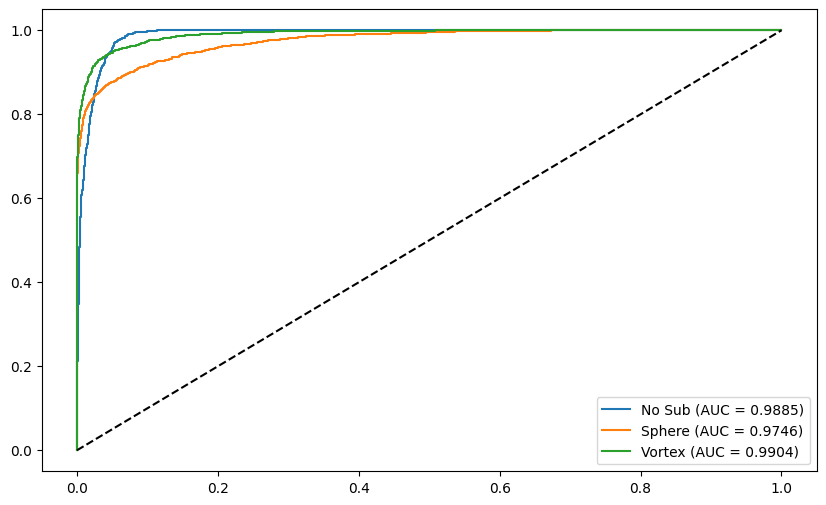

In [ ]:
epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    scheduler.step()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

# Final Metric Calculation
model.eval()
y_true, y_probs = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.to(device))
        y_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
        y_true.extend(labels.numpy())

y_probs, y_true = np.array(y_probs), np.array(y_true)
print(f"Final Ensemble Macro-AUC: {roc_auc_score(y_true, y_probs, multi_class='ovr'):.4f}")

# Plotting
plt.figure(figsize=(10, 6))
classes = ['No Sub', 'Sphere', 'Vortex']
for i in range(3):
    fpr, tpr, _ = roc_curve(y_true == i, y_probs[:, i])
    plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc_score(y_true == i, y_probs[:, i]):.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend(); plt.show()

In [ ]:
model_path = "/kaggle/working/lensing_ensemble_weights.pth"

torch.save(model.state_dict(), model_path)
print(f"Model weights saved to {model_path}")

Model weights saved to /kaggle/working/lensing_ensemble_weights.pth


In [14]:
torch.save(model, "/kaggle/working/lensing_ensemble_full.pth")